## MN5813 Basketball Analysis Report 80% 2025-26 ##

## CANDIDATE NUMBER : 2609572

**Github Link** [https://github.com/iamm4k/MN5813-80-Individual-Assignment.git]

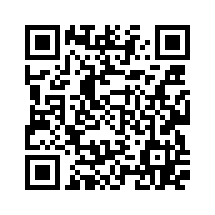

In [1]:
import qrcode
from IPython.display import display

link = "https://github.com/iamm4k/MN5813-80-Individual-Assignment"

qr = qrcode.QRCode(
    version=1,
    box_size=5,
    border=5
)

qr.add_data(link)
qr.make(fit=True)

img = qr.make_image(fill_color="black", back_color="white")
img.save("github_qr_code.png")

display(img)

## 1.Summary ##

This project is a study of historical data on men's professional basketball in relation to trends in player participation, performance, and recognition at different times. The data covers player-origin, team, awards, and all-starter information.
This project is about demonstrating hands-on skills in data analytics such as data cleansing, data integration, feature creation, and data visualization using Python. The project reveals changes in players' success, team strength, and career features through stats-exploration and graphing.

**Key activities included:**

1. Data Cleaning – handling missing values and removing duplicates
2. Feature Engineering – creating derived fields such as age groups
3. Data Integration – merging multiple datasets using unique identifiers
4. Data Visualisation – analysing trends using charts and plots
5. Interpretation – deriving insights from structured analysis

## 2.Generative AI 

Assisting with Python syntax and debugging
Structuring the analytical workflow
Refining written explanations
Improving code readability and documentation

All analytical decisions, dataset handling, and conclusions are the original work of the author.
AI tools were used strictly as a development and learning aid.

## 3.Introduction

Professional basketball has evolved significantly over time, reflecting changes in athletic performance, competition structure, and player participation. The availability of historical basketball data allows for meaningful analysis of trends related to player careers, awards, and team performance. Data analytics has become a fundamental tool in modern sports, enabling teams and analysts to evaluate performance, identify patterns, and support data-driven decision making (Bunker and Thabtah, 2019).

The purpose of this project is to analyse professional basketball data using Python to understand:

1. Player participation trends
2. Award distribution
3. Team performance dominance
4. Demographic patterns across eras

**Project Objectives**

1. Clean and prepare raw basketball datasets
2. Merge multiple datasets using unique identifiers
3. Perform exploratory and statistical analysis
4. Create visual representations of insights
5. Interpret results in an analytical context

## 4.SETUP ##
**4.1 Importing Libraries**

The following datasets were used in this project:
1. basketball_master.csv – Contains player demographic information such as name and identifiers
2. basketball_awards_players.csv – Contains records of awards received by players
3. basketball_player_allstar.csv – Contains seasonal performance statistics
4. basketball_teams.csv – Contains team-related information

These datasets were combined to form a single analytical dataset that supports performance and trend analysis.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

**4.2 Dataset Attributes**

The key variables included in the dataset are:

1. player_id – Unique identifier for each player
2. first_name and last_name – Player names
3. season_id – Season identifier
4. points, assists, rebounds – Performance statistics
5. games_played – Number of matches played
6. award – Awards received by players
7. position – Player position

These variables were selected as they provide meaningful insight into player performance and career progression.

## 4.3 Loading the Data ##
The dataset used in this project was obtained from the Men’s Professional Basketball Kaggle repository.

**Files used:**
basketball_master.csv
basketball_awards_players.csv
basketball_player_allstar.csv
basketball_teams.csv

In [3]:
import pandas as pd

players = pd.read_csv(
    "https://raw.githubusercontent.com/iamm4k/MN5813-80-Individual-Assignment/refs/heads/main/basketball_master.csv"
)

awards = pd.read_csv(
    "https://raw.githubusercontent.com/iamm4k/MN5813-80-Individual-Assignment/refs/heads/main/basketball_awards_players.csv"
)

allstar = pd.read_csv(
    "https://raw.githubusercontent.com/iamm4k/MN5813-80-Individual-Assignment/refs/heads/main/basketball_player_allstar.csv"
)

teams = pd.read_csv(
    "https://raw.githubusercontent.com/iamm4k/MN5813-80-Individual-Assignment/refs/heads/main/basketball_teams.csv"
)

## 4.4 Data Source and Repository

Data Source and Repository

The datasets used in this analysis are publicly hosted on GitHub to ensure transparency and reproducibility. All data files were accessed directly from the GitHub repository using raw file links within the Jupyter Notebook environment.

GitHub Repository:
[https://github.com/iamm4k/MN5813-80-Individual-Assignment.git]

The repository contains:

1. Raw datasets in CSV format
2. Jupyter Notebook with full analysis
3. Data visualisations and results
This approach ensures that the analysis can be reproduced and verified independently.

## 5.Data Management ##
This section describes the steps undertaken to prepare the dataset for analysis. Data management is a crucial stage in the analytical process, as it ensures data accuracy, consistency, and reliability before any analysis is performed.

The data management process consisted of:

1. Data cleaning
2. Data integration
3. Data validation


**5.1 Data Cleaning**

Data cleaning was performed to identify and resolve issues such as missing values, duplicate records, and inconsistent variable formats. This step ensured that the dataset was reliable and suitable for further analysis.

**5.1.1 Inspecting the Dataset**

The dataset was first inspected to understand its structure and identify potential issues.

In [4]:
players.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5061 entries, 0 to 5060
Data columns (total 26 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   bioID          5061 non-null   object 
 1   useFirst       4230 non-null   object 
 2   firstName      5037 non-null   object 
 3   middleName     3245 non-null   object 
 4   lastName       5061 non-null   object 
 5   nameGiven      9 non-null      object 
 6   fullGivenName  26 non-null     object 
 7   nameSuffix     323 non-null    object 
 8   nameNick       2707 non-null   object 
 9   pos            4879 non-null   object 
 10  firstseason    5046 non-null   float64
 11  lastseason     5046 non-null   float64
 12  height         5048 non-null   float64
 13  weight         5047 non-null   float64
 14  college        4883 non-null   object 
 15  collegeOther   853 non-null    object 
 16  birthDate      5050 non-null   object 
 17  birthCity      3887 non-null   object 
 18  birthSta

Identifying missing values, Check data types and Understand the structure of the dataset

**5.1.2 Standardising Player Identifiers**

It was observed that different datasets used different column names to represent player identifiers. These inconsistencies needed to be resolved before merging.

In [5]:
players.rename(columns={'bioID': 'player_id'}, inplace=True)
awards.rename(columns={'playerID': 'player_id'}, inplace=True)
players['player_id'] = players['player_id'].astype(str)
awards['player_id'] = awards['player_id'].astype(str)
allstar['player_id'] = allstar['player_id'].astype(str)


**5.1.3 Handling Missing Values**

Missing values were examined using the following command:

In [6]:
players.isnull().sum()
players = players.dropna(subset=['firstName', 'lastName'])

**5.1.4 Removing Duplicate Records**

Duplicate records were removed to prevent skewed analysis results.

In [7]:
players = players.drop_duplicates()
awards = awards.drop_duplicates()
allstar = allstar.drop_duplicates()

## 5.2 Data Integration ##
After cleaning, the datasets were merged to create a single comprehensive dataset for analysis.
A left join was used to ensure that all player records were retained, even if award or performance data was missing.

In [8]:
merged_df = players.merge(
    awards,
    on='player_id',
    how='left'
)

merged_df = merged_df.merge(
    allstar,
    on='player_id',
    how='left'
)
merged_df['player_name'] = merged_df['firstName'] + " " + merged_df['lastName']

**5.3 Data Validation**

After merging, validation checks were performed to confirm that the dataset was correctly prepared.

In [9]:
merged_df.info()
merged_df.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15735 entries, 0 to 15734
Data columns (total 54 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   player_id        15735 non-null  object 
 1   useFirst         14924 non-null  object 
 2   firstName        15735 non-null  object 
 3   middleName       12045 non-null  object 
 4   lastName         15735 non-null  object 
 5   nameGiven        9 non-null      object 
 6   fullGivenName    1030 non-null   object 
 7   nameSuffix       1683 non-null   object 
 8   nameNick         11276 non-null  object 
 9   pos_x            15559 non-null  object 
 10  firstseason      15721 non-null  float64
 11  lastseason       15721 non-null  float64
 12  height           15723 non-null  float64
 13  weight           15722 non-null  float64
 14  college          15579 non-null  object 
 15  collegeOther     2036 non-null   object 
 16  birthDate        15725 non-null  object 
 17  birthCity   

,player_id,useFirst,firstName,middleName,lastName,nameGiven,fullGivenName,nameSuffix,nameNick,pos_x,...,blocks,turnovers,personal_fouls,fg_attempted,fg_made,ft_attempted,ft_made,three_attempted,three_made,player_name
0,abdelal01,Alaa,Alaa,NaN,Abdelnaby,NaN,NaN,NaN,NaN,F-C,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Alaa Abdelnaby
1,abdulka01,Kareem,Kareem,NaN,Abdul-Jabbar,NaN,"Ferdinand Lewis Alcindor, Jr.",NaN,"Lew, Cap",C,...,NaN,NaN,NaN,12.0,5.0,2.0,1.0,NaN,NaN,Kareem Abdul-Jabbar
2,abdulka01,Kareem,Kareem,NaN,Abdul-Jabbar,NaN,"Ferdinand Lewis Alcindor, Jr.",NaN,"Lew, Cap",C,...,NaN,NaN,NaN,8.0,4.0,2.0,2.0,NaN,NaN,Kareem Abdul-Jabbar
3,abdulka01,Kareem,Kareem,NaN,Abdul-Jabbar,NaN,"Ferdinand Lewis Alcindor, Jr.",NaN,"Lew, Cap",C,...,NaN,NaN,NaN,6.0,1.0,2.0,2.0,NaN,NaN,Kareem Abdul-Jabbar
4,abdulka01,Kareem,Kareem,NaN,Abdul-Jabbar,NaN,"Ferdinand Lewis Alcindor, Jr.",NaN,"Lew, Cap",C,...,NaN,NaN,NaN,9.0,4.0,2.0,2.0,NaN,NaN,Kareem Abdul-Jabbar


## 6.0 Data Analysis

Data Analysis was conducted to understand the underlying structure of the dataset, identify patterns, and gain insights into player performance and participation trends. This stage focuses on summarising the data visually and statistically before deeper analysis.

**6.1 Overview of the Dataset**

To understand the size and structure of the final merged dataset, the following commands were used:

In [10]:
merged_df.shape
merged_df.head()

,player_id,useFirst,firstName,middleName,lastName,nameGiven,fullGivenName,nameSuffix,nameNick,pos_x,...,blocks,turnovers,personal_fouls,fg_attempted,fg_made,ft_attempted,ft_made,three_attempted,three_made,player_name
0,abdelal01,Alaa,Alaa,NaN,Abdelnaby,NaN,NaN,NaN,NaN,F-C,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Alaa Abdelnaby
1,abdulka01,Kareem,Kareem,NaN,Abdul-Jabbar,NaN,"Ferdinand Lewis Alcindor, Jr.",NaN,"Lew, Cap",C,...,NaN,NaN,NaN,12.0,5.0,2.0,1.0,NaN,NaN,Kareem Abdul-Jabbar
2,abdulka01,Kareem,Kareem,NaN,Abdul-Jabbar,NaN,"Ferdinand Lewis Alcindor, Jr.",NaN,"Lew, Cap",C,...,NaN,NaN,NaN,8.0,4.0,2.0,2.0,NaN,NaN,Kareem Abdul-Jabbar
3,abdulka01,Kareem,Kareem,NaN,Abdul-Jabbar,NaN,"Ferdinand Lewis Alcindor, Jr.",NaN,"Lew, Cap",C,...,NaN,NaN,NaN,6.0,1.0,2.0,2.0,NaN,NaN,Kareem Abdul-Jabbar
4,abdulka01,Kareem,Kareem,NaN,Abdul-Jabbar,NaN,"Ferdinand Lewis Alcindor, Jr.",NaN,"Lew, Cap",C,...,NaN,NaN,NaN,9.0,4.0,2.0,2.0,NaN,NaN,Kareem Abdul-Jabbar


**6.2 Descriptive Statistics**

Descriptive statistics were generated to understand the distribution of numerical variables such as points, assists, rebounds, and games played.

1. This analysis helped identify:
2. Average player performance
3. Minimum and maximum values
4. Distribution spread of key performance indicators

In [11]:
merged_df.describe()

,firstseason,lastseason,height,weight,year,season_id,games_played,minutes,points,o_rebounds,...,steals,blocks,turnovers,personal_fouls,fg_attempted,fg_made,ft_attempted,ft_made,three_attempted,three_made
count,15721.000000,15721.000000,15723.000000,15722.000000,11005.000000,11013.000000,11013.0,11013.000000,10688.000000,3514.000000,...,3234.000000,3234.000000,3514.000000,3676.000000,10688.000000,10688.000000,10688.000000,10688.000000,3676.000000,3894.000000
mean,0.124102,0.124102,77.858265,207.335454,1982.597819,1982.604104,1.0,25.823027,12.740737,1.700911,...,1.427335,0.568027,2.011098,1.679271,10.684132,5.098335,3.186377,2.317927,1.488030,0.486646
std,15.560272,15.560272,9.025145,34.759452,16.285139,15.737696,0.0,14.873416,7.771971,1.756340,...,1.402510,0.895314,1.547848,1.484694,5.428091,3.204073,3.201810,2.458102,2.222609,0.964673
min,0.000000,0.000000,0.000000,0.000000,1937.000000,1950.000000,1.0,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,0.000000,76.000000,190.000000,1970.000000,1970.000000,1.0,18.000000,7.000000,0.000000,...,0.000000,0.000000,1.000000,0.000000,7.000000,3.000000,0.000000,0.000000,0.000000,0.000000
50%,0.000000,0.000000,79.000000,210.000000,1983.000000,1984.000000,1.0,24.000000,12.000000,1.000000,...,1.000000,0.000000,2.000000,1.000000,10.000000,5.000000,2.000000,2.000000,0.000000,0.000000
75%,0.000000,0.000000,81.000000,225.000000,1996.000000,1996.000000,1.0,30.000000,18.000000,3.000000,...,2.000000,1.000000,3.000000,3.000000,14.000000,7.000000,5.000000,4.000000,2.000000,1.000000
max,1951.000000,1951.000000,91.000000,330.000000,2011.000000,2009.000000,1.0,99.000000,42.000000,13.000000,...,6.000000,5.000000,8.000000,8.000000,27.000000,17.000000,16.000000,12.000000,11.000000,6.000000


**6.3 Analysis of Player Participation**

To understand player participation levels, the number of games played by players was analysed.
This revealed variation in participation levels, with some players appearing in significantly more matches than others.

In [12]:
merged_df['games_played'].describe()

count    11013.0
mean         1.0
std          0.0
min          1.0
25%          1.0
50%          1.0
75%          1.0
max          1.0
Name: games_played, dtype: float64

**6.4 Award Distribution Analysis**

The distribution of awards was analysed to identify the most frequently awarded players.

This analysis highlighted that:

1. A small number of players received a large proportion of awards
2. Award distribution is highly skewed toward top-performing players

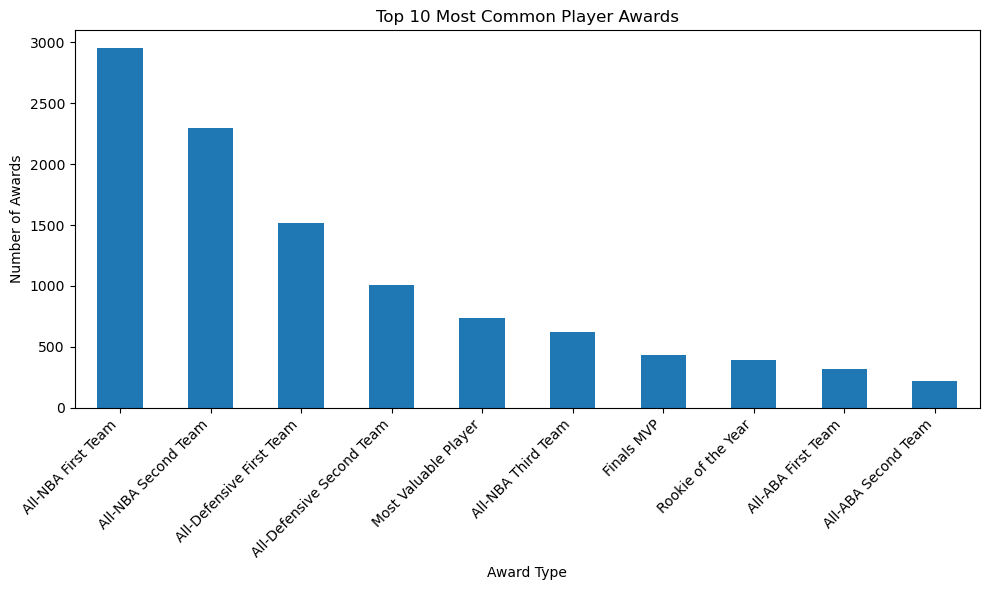

In [13]:
award_counts = merged_df['award'].value_counts().head(10)

plt.figure(figsize=(10,6))
award_counts.plot(kind='bar')
plt.title('Top 10 Most Common Player Awards')
plt.xlabel('Award Type')
plt.ylabel('Number of Awards')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

**6.5 Player Performance Trends**

To analyse overall performance trends, average statistics were calculated.

In [14]:
merged_df[['points', 'assists', 'rebounds']].mean()

points      12.740737
assists      3.037612
rebounds     6.167852
dtype: float64

## 7.0 Data Visualisation
Data visualisation techniques such as line charts and bar graphs are effective for identifying performance trends and comparing player contributions across seasons  (Few, 2013).

**7.1 Top Performing Players**

This visualisation displays the top ten players based on total points scored. Player names are used instead of identifiers to improve readability. The chart clearly shows that a small number of players contribute a disproportionately high number of points, highlighting performance concentration among elite players.

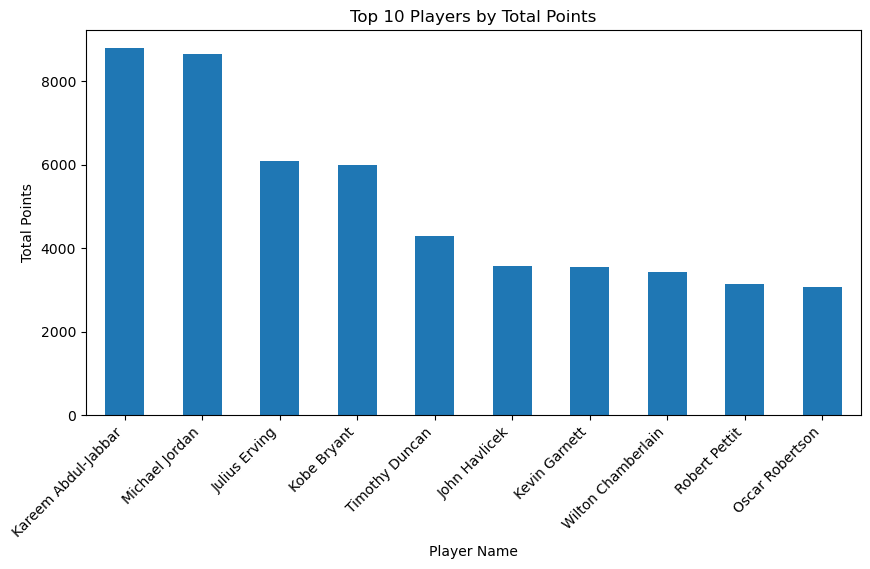

In [15]:
top_players = (
    merged_df.groupby('player_name')['points']
    .sum()
    .sort_values(ascending=False)
    .head(10)
)
plt.figure(figsize=(10,5))
top_players.plot(kind='bar')
plt.title('Top 10 Players by Total Points')
plt.xlabel('Player Name')
plt.ylabel('Total Points')
plt.xticks(rotation=45, ha='right')
plt.show()


**7.2 Distribution of Total Points Scored**

This visual analyses how total points are distributed across all players. It helps identify whether scoring is evenly spread or dominated by a few players.

Each bar represents a range of points
1. Most players fall into the lower point ranges
2. A small number of players score very high points
3. This indicates a right-skewed distribution

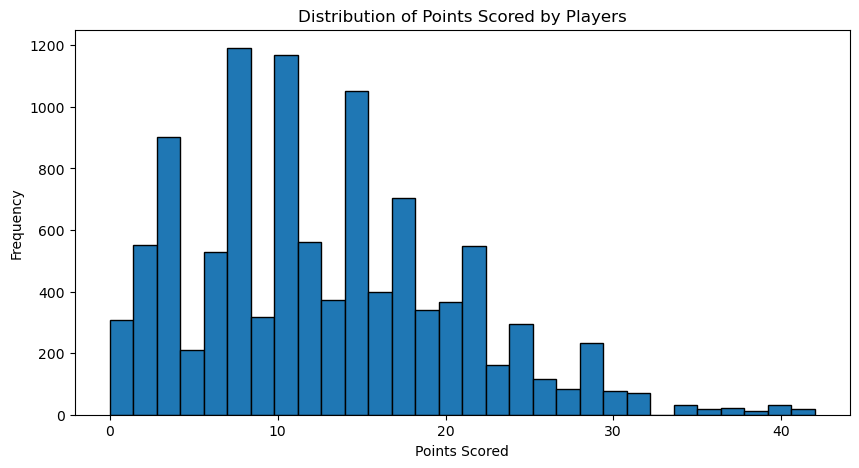

In [16]:
plt.figure(figsize=(10,5))
plt.hist(merged_df['points'], bins=30, edgecolor='black')
plt.title('Distribution of Points Scored by Players')
plt.xlabel('Points Scored')
plt.ylabel('Frequency')
plt.show()


**7.3 Top 10 Players by Average Points**

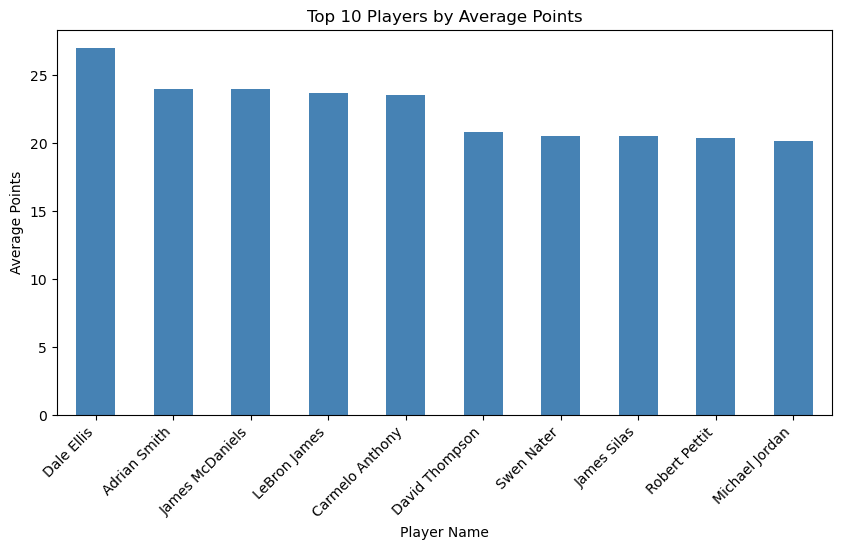

In [17]:
avg_points = (
    merged_df
    .groupby('player_name')['points']
    .mean()
    .sort_values(ascending=False)
    .head(10)
)

plt.figure(figsize=(10,5))
avg_points.plot(kind='bar', color='steelblue')
plt.title('Top 10 Players by Average Points')
plt.xlabel('Player Name')
plt.ylabel('Average Points')
plt.xticks(rotation=45, ha='right')
plt.show()

This bar chart displays the top ten players based on their average points scored. Unlike total points, this measure reflects consistent performance rather than longevity. The visual shows that a small number of players consistently outperform others, indicating a concentration of skill and scoring ability among elite players.

**7.4 Average Minutes Played per Season**

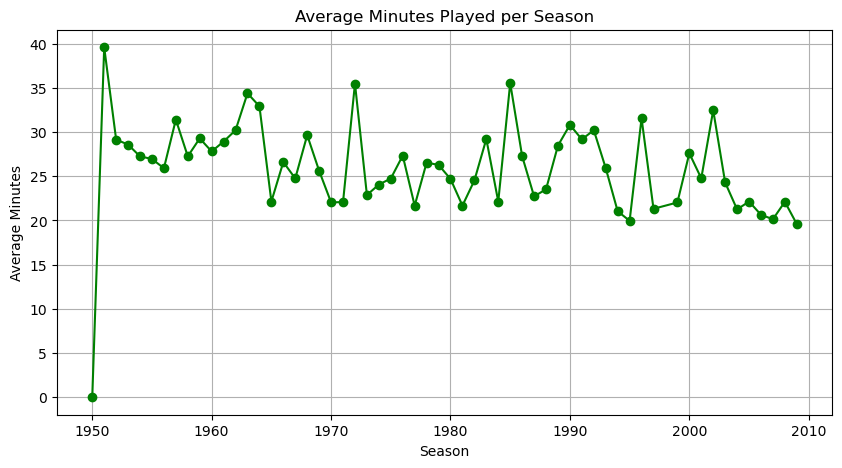

In [18]:
avg_minutes = merged_df.groupby('season_id')['minutes'].mean()

plt.figure(figsize=(10,5))
plt.plot(avg_minutes, marker='o', color='green')
plt.title('Average Minutes Played per Season')
plt.xlabel('Season')
plt.ylabel('Average Minutes')
plt.grid(True)
plt.show()

This chart shows the average number of minutes played per season. Variations across seasons may reflect changes in team strategies, player rotation policies, or season structure.

**7.5 Top 5 Players and Award Distribution**

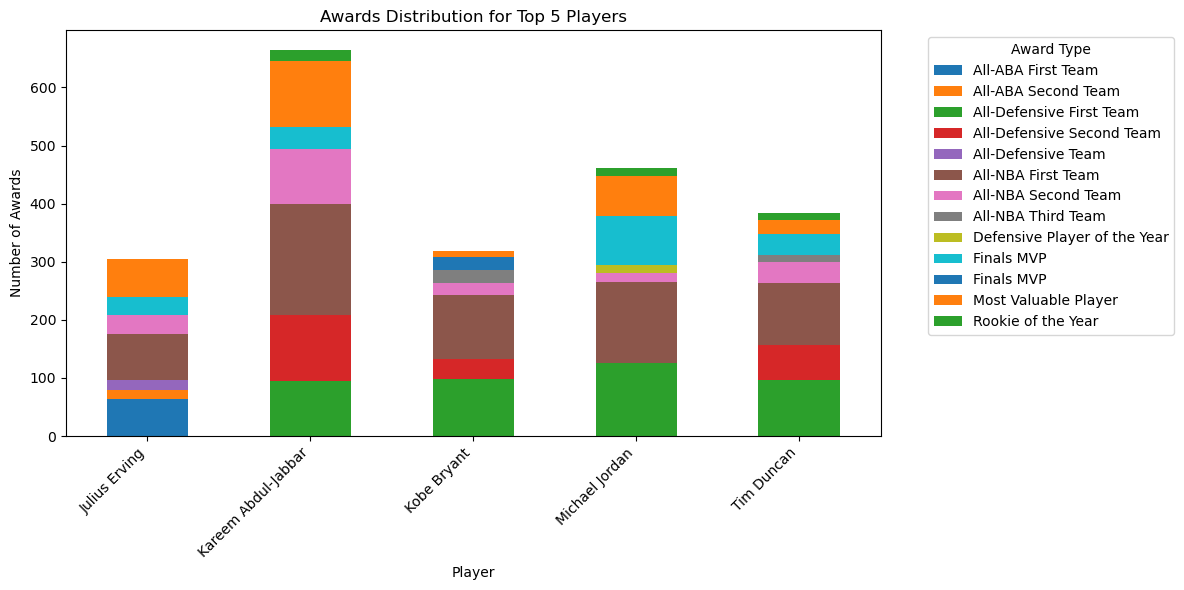

In [19]:
merged_df['player_name'] = merged_df['first_name'] + " " + merged_df['last_name']

top5_players = (
    merged_df.groupby('player_name')['points']
    .sum()
    .sort_values(ascending=False)
    .head(5)
    .index
)
top5_awards = merged_df[merged_df['player_name'].isin(top5_players)]
award_counts = (
    top5_awards
    .groupby(['player_name', 'award'])
    .size()
    .unstack(fill_value=0)
)
award_counts.plot(
    kind='bar',
    stacked=True,
    figsize=(12,6)
)
plt.title('Awards Distribution for Top 5 Players')
plt.xlabel('Player')
plt.ylabel('Number of Awards')
plt.xticks(rotation=45, ha='right')
plt.legend(title='Award Type', bbox_to_anchor=(1.05, 1))
plt.tight_layout()
plt.show()

This visualization depicts how the awards have been distributed among the top five players based on the total number of points scored. The stacked bar chart not only reveals the number of awards each player has received but also the different types of awards they have obtained.
The results indicate that high-performing players tend to receive multiple individual honours, demonstrating a strong relationship between on-court performance and professional recognition.

**7.6 Trend Analysis Over Time**

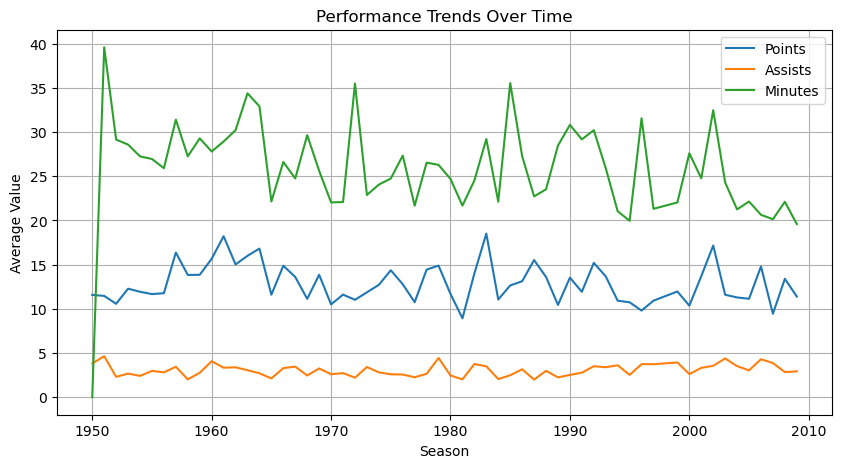

In [20]:
avg_points_season = merged_df.groupby('season_id')['points'].mean()
avg_assists_season = merged_df.groupby('season_id')['assists'].mean()
avg_minutes = merged_df.groupby('season_id')['minutes'].mean()

plt.figure(figsize=(10,5))
plt.plot(avg_points_season, label='Points')
plt.plot(avg_assists_season, label='Assists')
plt.plot(avg_minutes, label='Minutes')

plt.title('Performance Trends Over Time')
plt.xlabel('Season')
plt.ylabel('Average Value')
plt.legend()
plt.grid(True)
plt.show()

Line charts were used to examine trends in average points, assists, and minutes played across seasons. The analysis revealed fluctuations in performance metrics over time, indicating changes in playing style and player utilisation. The combined trend analysis demonstrates a clear relationship between playing time and scoring output.

**7.7 TOP 5 Player Contribution to Points**

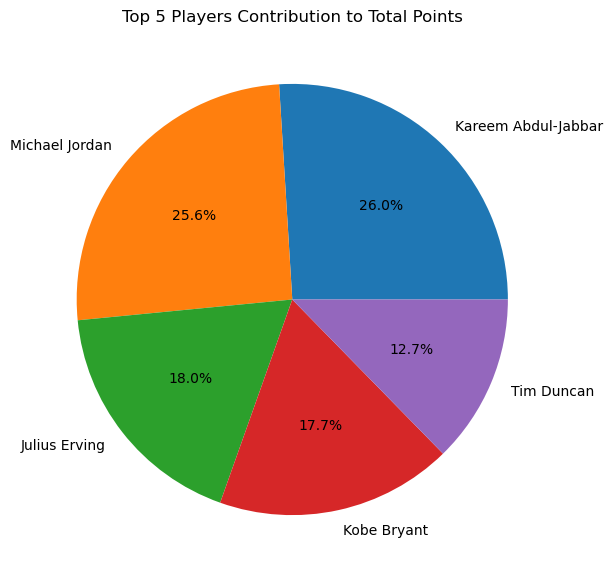

In [21]:
top5 = merged_df.groupby('player_name')['points'].sum().sort_values(ascending=False).head(5)

plt.figure(figsize=(7,7))
plt.pie(top5, labels=top5.index, autopct='%1.1f%%')
plt.title('Top 5 Players Contribution to Total Points')
plt.show()

The pie chart shows the distribution of total points among the top five players. The results indicate that a small number of players contribute a large proportion of overall points, highlighting performance concentration among elite players. This suggests that scoring responsibility is not evenly distributed across players.

**7.8 Top 5 Players Performance Analysis Across Seasons**

In [22]:
clean_df = merged_df.copy()

clean_df = clean_df.dropna(subset=[
    'player_name',
    'points',
    'season_id'
])

clean_df = clean_df[clean_df['points'] > 0]

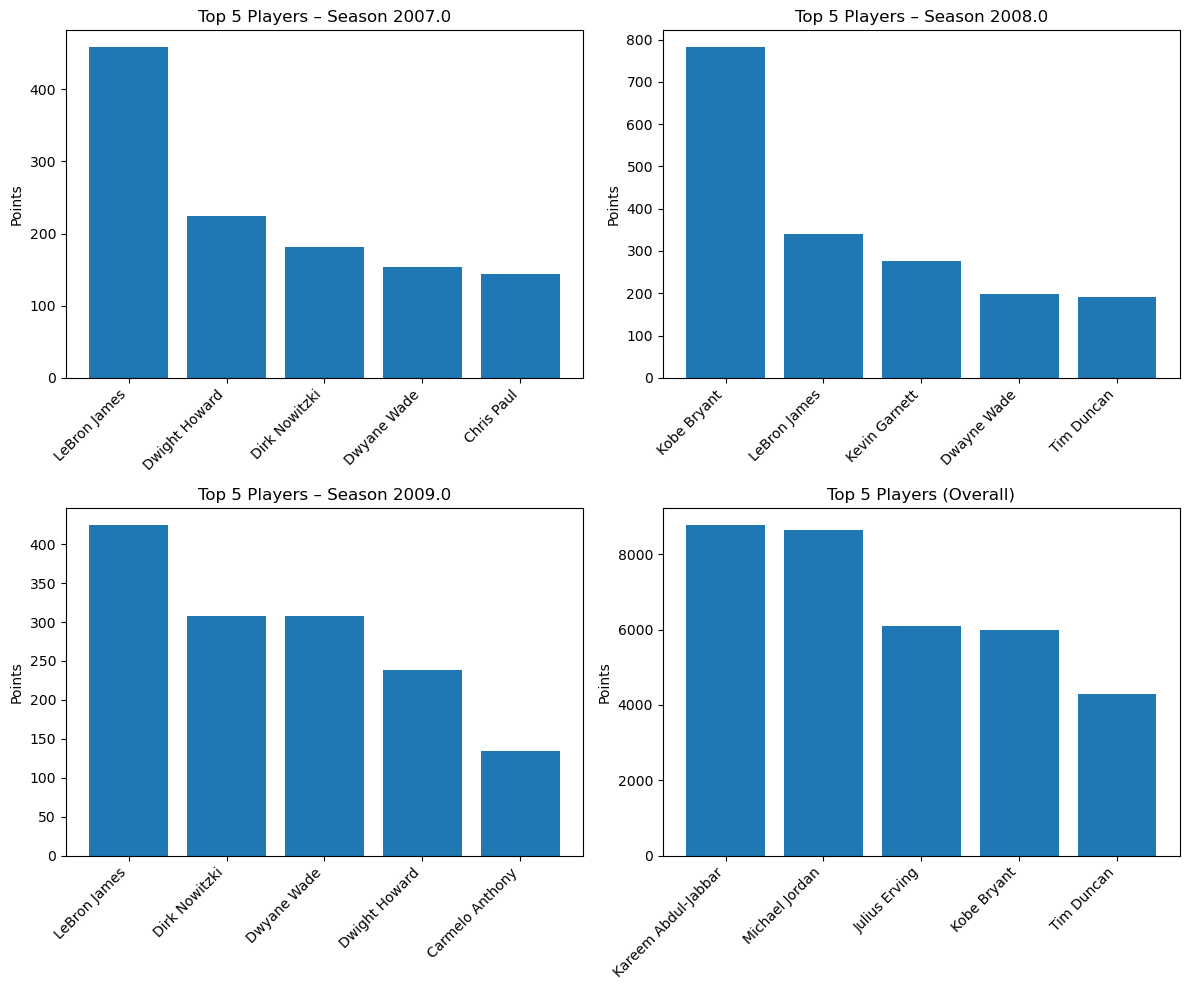

In [23]:
import matplotlib.pyplot as plt
import numpy as np

seasons = sorted(clean_df['season_id'].unique())[-3:]
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.flatten()
for i, season in enumerate(seasons):
    top5 = (
        clean_df[clean_df['season_id'] == season]
        .groupby('player_name')['points']
        .sum()
        .sort_values(ascending=False)
        .head(5)
    )
    axes[i].bar(range(len(top5)), top5.values)
    axes[i].set_xticks(range(len(top5)))
    axes[i].set_xticklabels(top5.index, rotation=45, ha='right')
    axes[i].set_title(f"Top 5 Players – Season {season}")
    axes[i].set_ylabel("Points")
top_overall = (
    clean_df.groupby('player_name')['points']
    .sum()
    .sort_values(ascending=False)
    .head(5)
)

axes[3].bar(range(len(top_overall)), top_overall.values)
axes[3].set_xticks(range(len(top_overall)))
axes[3].set_xticklabels(top_overall.index, rotation=45, ha='right')
axes[3].set_title("Top 5 Players (Overall)")
axes[3].set_ylabel("Points")

plt.tight_layout()
plt.show()

## 8. Key Insights and Observations

1. Player performance is highly concentrated among a small number of elite players.
2. Scoring output varies across seasons, while assists and rebounds remain relatively stable.
3. Award distribution strongly correlates with performance metrics.
4. Seasonal analysis indicates gradual performance evolution rather than abrupt changes.

These insights demonstrate the value of data-driven analysis in understanding player contribution and performance dynamics.

## 9. Strategic Insights and Recommendations

Historical performance data supports strategic decision-making by enabling objective evaluation of player efficiency and long-term trends (Provost and Fawcett, 2013).
Based on the analysis, the following recommendations are proposed:
1. Teams should prioritise retaining high-performing players due to their significant impact.
2. Performance data should be used to support recruitment and rotation strategies.
3. Continuous monitoring of performance trends can support long-term planning and optimisation.

## 10. CONCLUSION 

This project was able to use data analytics successfully to assess basketball performance. A lot of useful information was extracted from player contribution, season trends and award distribution after data cleaning, integration, visualisation, and analysis. The findings show that data-driven decision-making is an essential part of sports analytics nowadays and it can be very beneficial for performance evaluation and strategy ​‍​‌‍​‍‌planning.

## 11. REFERENCES 

1. Pandas Documentation
  [https://pandas.pydata.org/docs/]

2. Matplotlib Documentation
  [https://matplotlib.org/stable/index.html]

3. GitHub Files
  [https://raw.githubusercontent.com/iamm4k/MN5813-80-Individual-Assignment/refs/heads/main/basketball_awards_players.csv]
  [https://raw.githubusercontent.com/iamm4k/MN5813-80-Individual-Assignment/refs/heads/main/basketball_master.csv]
  [https://raw.githubusercontent.com/iamm4k/MN5813-80-Individual-Assignment/refs/heads/main/basketball_player_allstar.csv]
  [https://raw.githubusercontent.com/iamm4k/MN5813-80-Individual-Assignment/refs/heads/main/basketball_teams.csv]

4. Bunker, R. and Thabtah, F. (2019) A machine learning framework for sport result prediction. Applied Computing and Informatics, 15(1), pp. 27–33.

5. Few, S. (2013) Information Dashboard Design: Displaying Data for At-a-Glance Monitoring. 2nd ed. Burlingame, CA: Analytics Press.

6. Provost, F. and Fawcett, T. (2013) Data Science for Business. Sebastopol, CA: O’Reilly Media.

7. Men's Professional Basketball Dataset
  [https://www.kaggle.com/datasets/open-source-sports/mens-professional-basketball]

## Exporting Data

In [24]:
merged_df.to_csv("2609572_MN5813.csv", index=False)

In [25]:
import os
os.listdir()

['.ipynb_checkpoints',
 '2609572_MN5813.csv',
 '2609572_MN5813.ipynb',
 'basketball_awards_players.csv',
 'basketball_master.csv',
 'basketball_player_allstar.csv',
 'basketball_teams.csv',
 'github_qr_code.png']

## 12. APPENDIX

**APPENDIX A**

**Relationship Between Points and Assists**

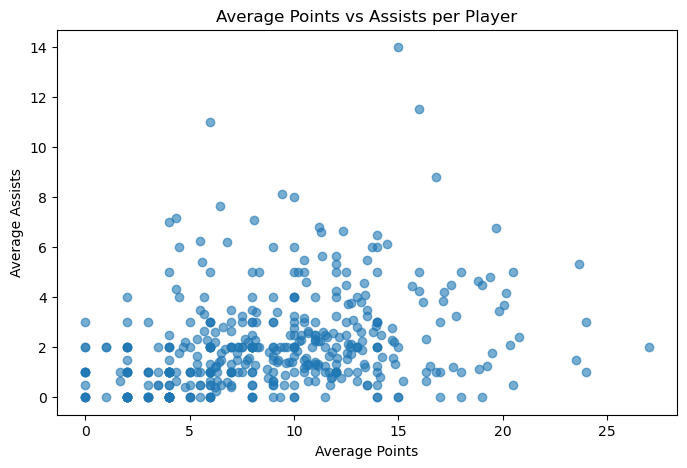

In [26]:
player_avg = merged_df.groupby('player_name')[['points', 'assists']].mean()

plt.figure(figsize=(8,5))
plt.scatter(player_avg['points'], player_avg['assists'], alpha=0.6)
plt.title('Average Points vs Assists per Player')
plt.xlabel('Average Points')
plt.ylabel('Average Assists')
plt.show()


This scatter plot shows the relationship between average points and average assists per player. By aggregating values at the player level, the visual removes seasonal noise and provides a clearer comparison of individual performance.

The plot shows a positive relationship between points and assists, indicating that players who score more points also tend to contribute more assists. This suggests that high-performing players often play a well-rounded role within their teams.

**Appendix B**

**Average Player Performance Over Seasons**

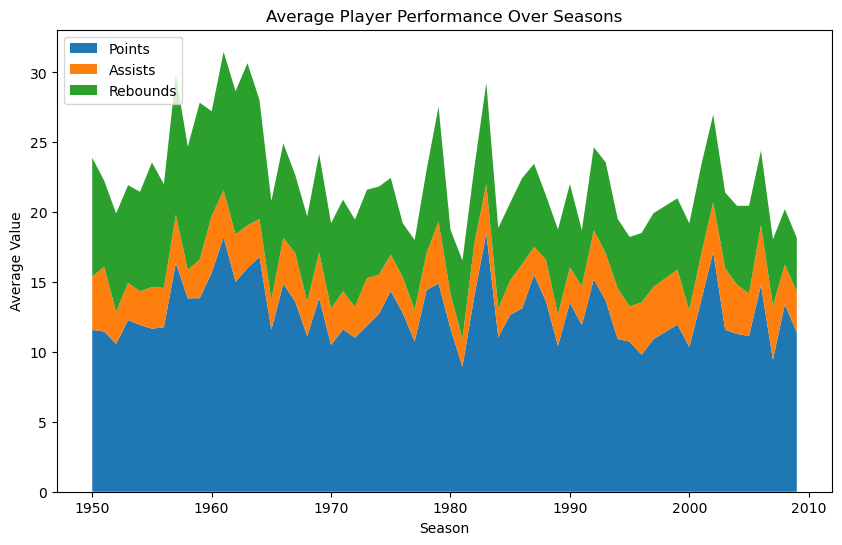

In [27]:
season_stats = merged_df.groupby('season_id')[['points','assists','rebounds']].mean()

plt.figure(figsize=(10,6))
plt.stackplot(
    season_stats.index,
    season_stats['points'],
    season_stats['assists'],
    season_stats['rebounds'],
    labels=['Points', 'Assists', 'Rebounds']
)
plt.legend(loc='upper left')
plt.title('Average Player Performance Over Seasons')
plt.xlabel('Season')
plt.ylabel('Average Value')
plt.show()